/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_8786/618502419.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()
/var/folders/27/vz2x5s696jv_fnk5tpw5z1gw0000gn/T/ipykernel_8786/618502419.py:151: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(frameon=False, ncol=2, fontsize=7, handlelength=1.5)


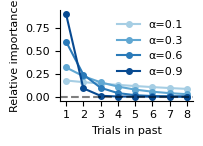

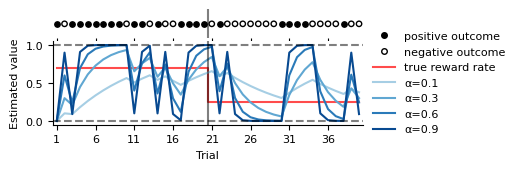

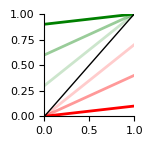

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# fontsize = 8
plt.rcParams.update({'font.size': 8})

def despine(ax):
    """Hide top/right spines (matplotlib-only 'despine')."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ---------- Common settings ----------
alphas = [0.1, 0.3, 0.6, 0.9]   # four learning rates
height_in = 1.5                 # keep same height for all figures
width_in_small = 2              # modest width for “small” figures
width_in_large = 4              # larger width for “large” figures

# Color gradient: light -> dark blues for the alpha curves
cmap = plt.cm.Blues
curve_colors = cmap(np.linspace(0.35, 0.9, len(alphas)))

# ---------- Figure 1: Relative importance over last n=8 feedback ----------
n = 8
k = np.arange(1, n + 1)  # trials in past: 1..8
fig1, ax1 = plt.subplots(figsize=(width_in_small, height_in))

for color, a in zip(curve_colors, alphas):
    # Exponential recency weighting (normalized over the last n trials)
    w = a * (1 - a) ** (k - 1)
    w = w / w.sum()
    ax1.plot(k, w, marker='o', markersize=4, color=color, label=f'α={a}')

ax1.axhline(0, color='k', linestyle='--', alpha=0.5)
ax1.set_xlabel('Trials in past')
ax1.set_ylabel('Relative importance')
ax1.set_xticks(k)
ax1.legend(frameon=False)
despine(ax1)
fig1.tight_layout()
fig1.savefig('figs/fig1_relative_importance.svg', bbox_inches='tight', transparent=True)

# ---------- Figure 2: Stochastic outcomes with flipping reward rate ----------
T = 40
block_size = 20
trials = np.arange(1, T + 1)

# True reward-rate schedule (flip every block_size trials)
reward_rate = np.array([0.7 if ((i - 1) // block_size) % 2 == 0 else 0.25
                        for i in range(1, T + 1)])

# Sample outcomes stochastically from the true rates
'''random_int = np.random.randint(0, 10000)
print(f"Random seed for outcomes: {random_int}")'''
rng2 = np.random.default_rng(7708)
outcomes = rng2.binomial(1, reward_rate).tolist()

# Figure with a small outcome strip on top + main panel below (same overall height)
fig2 = plt.figure(figsize=(width_in_large, height_in))
gs = fig2.add_gridspec(nrows=2, ncols=1, height_ratios=[0.35, 1.0], hspace=0.05)
ax2_top = fig2.add_subplot(gs[0])
ax2 = fig2.add_subplot(gs[1], sharex=ax2_top)

# --- Top outcome strip (filled = positive, empty = negative) ---
ax2_top.set_xlim(0.5, T + 0.5)
ax2_top.set_ylim(0, 1)
for i, r in enumerate(outcomes, start=1):
    if r == 1:
        ax2_top.scatter(i, 0.5, s=15, facecolor='k', edgecolor='k')
    else:
        ax2_top.scatter(i, 0.5, s=15, facecolor='none', edgecolor='k')
# Mark block boundaries on the strip
for xline in np.arange(block_size + 0.5, T + 0.5, block_size):
    ax2_top.axvline(xline, color='k', linestyle='-', alpha=0.5)
# Hide all decoration on the strip
ax2_top.set_xticks([])
ax2_top.set_yticks([])
for spine in ax2_top.spines.values():
    spine.set_visible(False)

# --- Main panel: values under delta-rule for four learning rates ---
ax2.set_xlim(0.5, T + 0.5)
ax2.set_ylim(-0.05, 1.05)

# True reward rate in the background (red step line)
ax2.step(trials, reward_rate, where='mid', color='red', linewidth=1.5, alpha=0.7,
         label='true reward rate', zorder=0)

for color, a in zip(curve_colors, alphas):
    V = 0.0
    values = []
    for r in outcomes:
        values.append(V)                 # value at the start of trial t
        V = V + a * (r - V)              # update with outcome r
    ax2.plot(trials, values, color=color, linewidth=1.5, label=f'α={a}')

# Reference lines and block boundaries
ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
ax2.axhline(1, color='k', linestyle='--', alpha=0.5)
for xline in np.arange(block_size + 0.5, T + 0.5, block_size):
    ax2.axvline(xline, color='k', linestyle='-', alpha=0.5)

ax2.set_xticks(trials[::5])
ax2.set_xlabel('Trial')
ax2.set_ylabel('Estimated value')

# Legend with outcome markers + alpha curves
m_filled = plt.Line2D([], [], color='k', marker='o', linestyle='None',
                      markersize=4, label='positive outcome')
m_empty = plt.Line2D([], [], color='k', marker='o', linestyle='None',
                     markersize=4, markerfacecolor='none', label='negative outcome')
handles, labels = ax2.get_legend_handles_labels()
handles = [m_filled, m_empty] + handles
labels = [m.get_label() for m in [m_filled, m_empty]] + labels
ax2.legend(handles, labels, frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))

despine(ax2)
fig2.tight_layout()
fig2.savefig('figs/fig2_session_values.svg', bbox_inches='tight', transparent=True)

# ---------- Figure 3: V_t vs V_{t+1} across three α's ----------
alphas_fig3 = [0.3, 0.6, 0.9]          # three learning rates
transparencies = [0.2, 0.4, 1]       # three levels of point transparency

fig3, ax3 = plt.subplots(figsize=(height_in, height_in))

rng = np.random.default_rng(0)
V_t_samples = rng.uniform(0, 1, size=200)

x = np.linspace(0, 1, 200)

for a, atrans in zip(alphas_fig3, transparencies):
    # next-step values under positive (r=1) and negative (r=0) outcomes
    V_tp1_pos = (1 - a) * V_t_samples + a * 1.0
    V_tp1_neg = (1 - a) * V_t_samples + a * 0.0

    # scatter: green for positive, red for negative; transparency encodes α
    '''ax3.scatter(V_t_samples, V_tp1_pos, s=14, color='green', alpha=atrans, label=f'α={a} (pos)')
    ax3.scatter(V_t_samples, V_tp1_neg, s=14, color='red',   alpha=atrans, label=f'α={a} (neg)')'''

    # theoretical lines
    ax3.plot(x, (1 - a) * x + a, color='green', alpha=atrans, linewidth=2)
    ax3.plot(x, (1 - a) * x,     color='red',   alpha=atrans, linewidth=2)

# identity line y = x in black
ax3.plot([0, 1], [0, 1], color='k', linewidth=1)

ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
#ax3.set_xlabel('value at trial t (V_t)')
#ax3.set_ylabel('value at trial t+1 (V_{t+1})')
ax3.legend(frameon=False, ncol=2, fontsize=7, handlelength=1.5)
despine(ax3)
fig3.tight_layout()
fig3.savefig('figs/fig3_Vt_vs_Vt1_multi_alpha.svg', bbox_inches='tight', transparent=True)


plt.show()
